<a href="https://colab.research.google.com/github/yalindi/2425568_ml/blob/main/2425568.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!git clone https://github.com/yalindi/2425568_ml.git

Cloning into '2425568_ml'...
remote: Enumerating objects: 78, done.
remote: Counting objects: 100% (78/78), done.
remote: Compressing objects: 100% (71/71), done.
remote: Total 78 (delta 38), reused 20 (delta 4), pack-reused 0 (from 0)
Receiving objects: 100% (78/78), 2.37 MiB | 6.30 MiB/s, done.
Resolving deltas: 100% (38/38), done.


##**Import libraries**


In [3]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder,StandardScaler
from sklearn.tree import DecisionTreeClassifier

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn


%matplotlib inline

from sklearn.model_selection import train_test_split,cross_val_score
from sklearn.model_selection import RandomizedSearchCV,GridSearchCV
from sklearn.metrics import confusion_matrix,classification_report
from sklearn.metrics import precision_score,recall_score,f1_score,accuracy_score
from sklearn.metrics import RocCurveDisplay,roc_auc_score
from sklearn.metrics import ConfusionMatrixDisplay


# **Data** **exploration** **and** **Preprocessing** **Data**

In [5]:
df = pd.read_csv('/content/2425568_ml/WA_Fn-UseC_-Telco-Customer-Churn.csv')

In [6]:
df.shape

(7043, 21)

In [7]:
df.head().T

,0,1,2,3,4
customerID,7590-VHVEG,5575-GNVDE,3668-QPYBK,7795-CFOCW,9237-HQITU
gender,Female,Male,Male,Male,Female
SeniorCitizen,0,0,0,0,0
Partner,Yes,No,No,No,No
Dependents,No,No,No,No,No
tenure,1,34,2,45,2
PhoneService,No,Yes,Yes,No,Yes
MultipleLines,No phone service,No,No,No phone service,No
InternetService,DSL,DSL,DSL,DSL,Fiber optic
OnlineSecurity,No,Yes,Yes,Yes,No


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [9]:
#checking missing values
df.isna().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [10]:
df['Churn'].value_counts()

,count
Churn,
No,5174
Yes,1869


Text(0, 0.5, 'count')

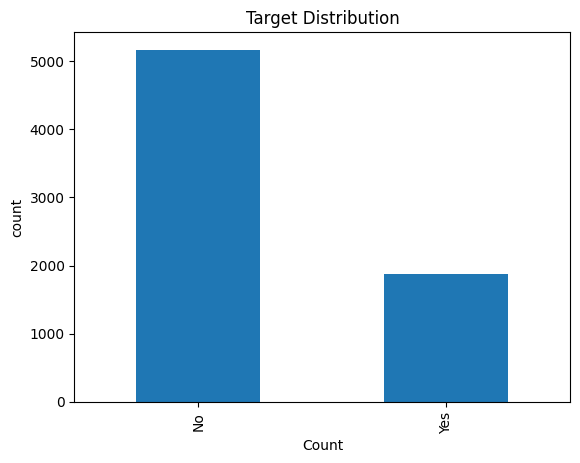

In [11]:
#Traget Distribution
df['Churn'].value_counts().plot(kind='bar')
plt.title("Target Distribution")
plt.xlabel("Count")
plt.ylabel("count")

In [12]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [13]:
df.describe(include="object")

,customerID,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,TotalCharges,Churn
count,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043
unique,7043,2,2,2,2,3,3,3,3,3,3,3,3,3,2,4,6531,2
top,3186-AJIEK,Male,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,,No
freq,1,3555,3641,4933,6361,3390,3096,3498,3088,3095,3473,2810,2785,3875,4171,2365,11,5174


In [14]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

In [15]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


Text(0.5, 1.0, 'tenure Distribution in Churn groups')

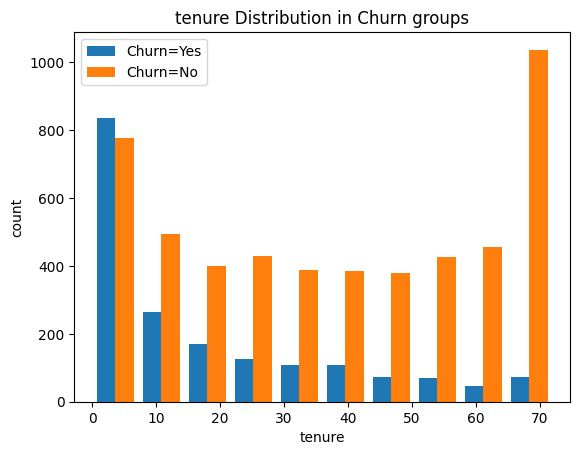

In [16]:
tenure_churn_no=df[df.Churn=='No'].tenure
tenure_churn_yes=df[df.Churn=='Yes'].tenure

plt.hist([tenure_churn_yes,tenure_churn_no])
plt.legend(['Churn=Yes','Churn=No'])
plt.xlabel('tenure')
plt.ylabel('count')
plt.title('tenure Distribution in Churn groups')

Text(0, 0.5, 'count')

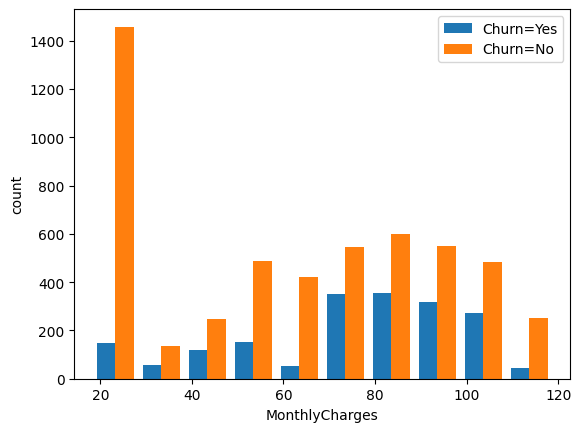

In [17]:
MonthlyCharges_churn_no=df[df.Churn=='No'].MonthlyCharges
MonthlyCharges_churn_yes=df[df.Churn=='Yes'].MonthlyCharges

plt.hist([MonthlyCharges_churn_yes,MonthlyCharges_churn_no])
plt.legend(['Churn=Yes','Churn=No'])
plt.xlabel('MonthlyCharges')
plt.ylabel('count')

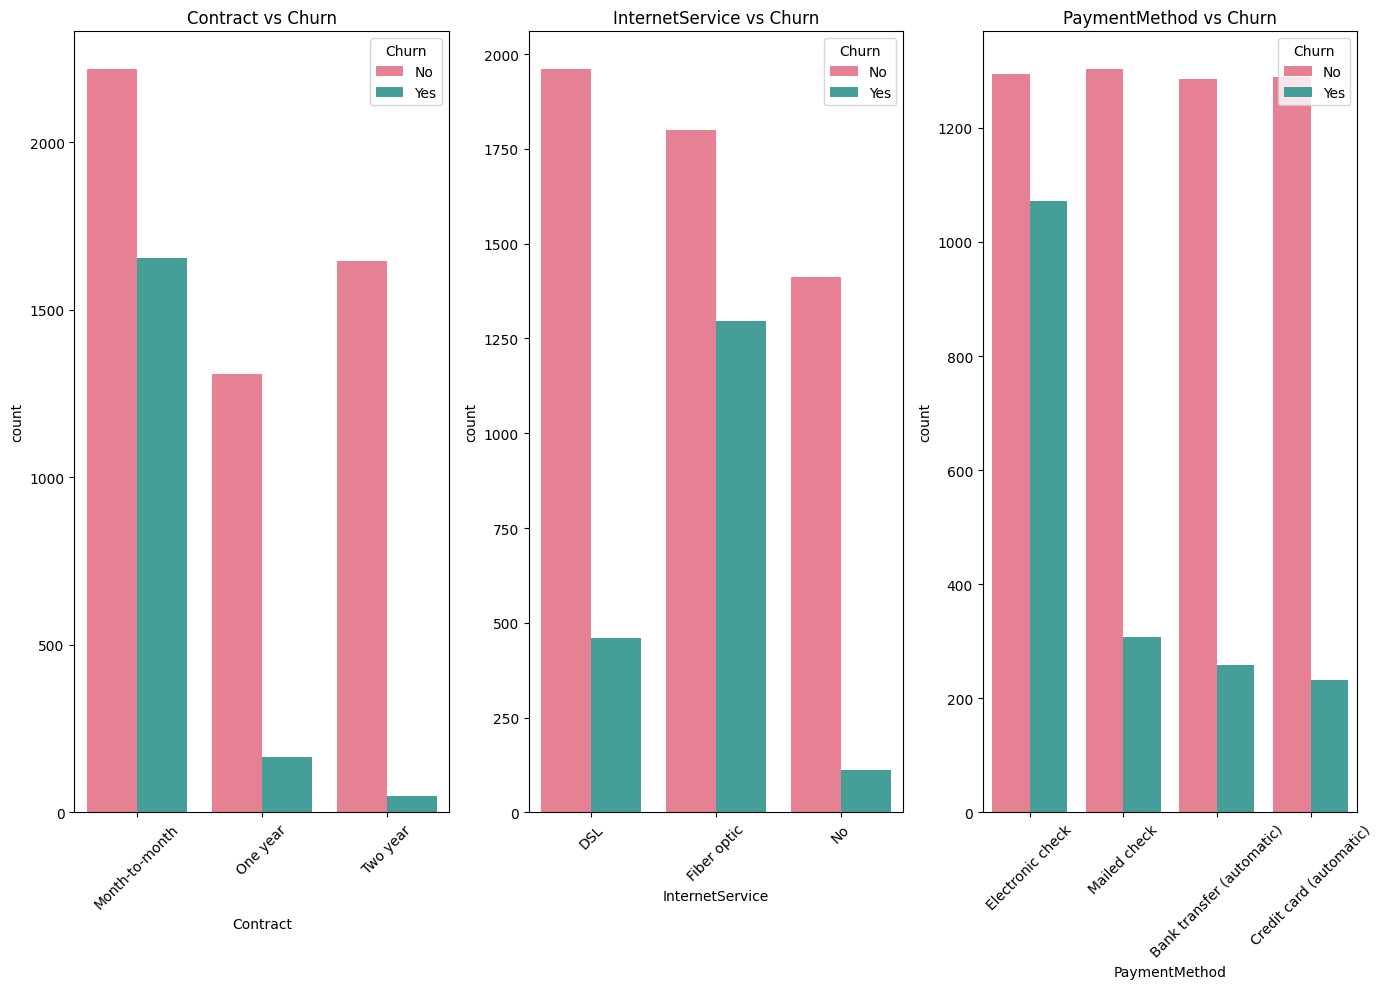

In [18]:
#Importanat categorical Features vs Churn
cat_cols = ['Contract', 'InternetService', 'PaymentMethod']

fig, axes = plt.subplots(1, 3, figsize=(14, 10))
axes = axes.ravel()
for i, col in enumerate(cat_cols):
    sns.countplot(data=df, x=col, hue='Churn', ax=axes[i], palette='husl')
    axes[i].set_title(f'{col} vs Churn')
    axes[i].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

In [19]:
df_copy=df.copy()
df_copy[df_copy.TotalCharges.isnull()==True]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,NaN,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,NaN,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,NaN,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,NaN,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,...,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,NaN,No


In [20]:
#Impute missing TotalCharges
df_copy['TotalCharges']=df_copy['TotalCharges'].fillna(0)


In [21]:
df_copy.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


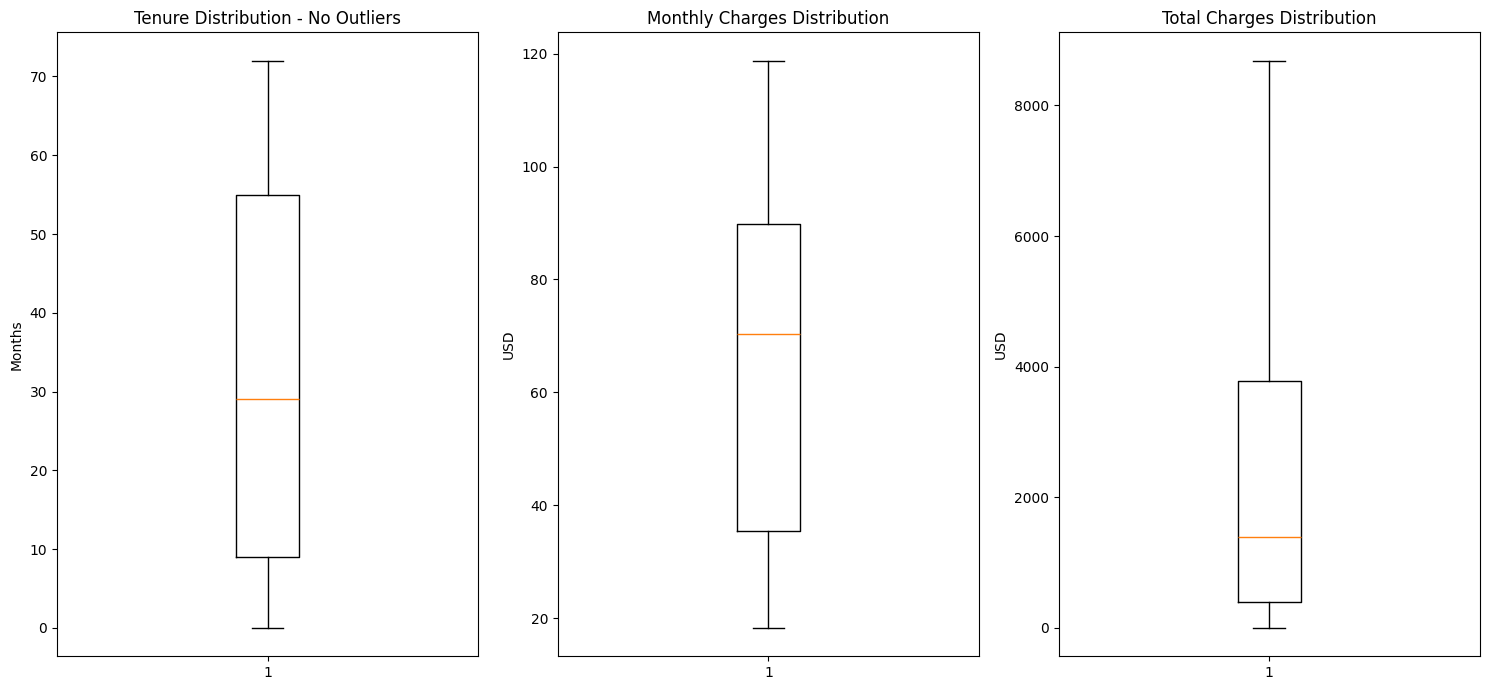

In [22]:
#detect outliers
fig, axes = plt.subplots(1, 3, figsize=(15, 7))

# Tenure outliers
axes[0].boxplot(df_copy['tenure'])
axes[0].set_title('Tenure Distribution - No Outliers')
axes[0].set_ylabel('Months')

# Monthly Charges outliers
axes[1].boxplot(df_copy['MonthlyCharges'])
axes[1].set_title('Monthly Charges Distribution')
axes[1].set_ylabel('USD')

# Total Charges outliers
axes[2].boxplot(df_copy['TotalCharges'])
axes[2].set_title('Total Charges Distribution')
axes[2].set_ylabel('USD')

plt.tight_layout()
plt.show()

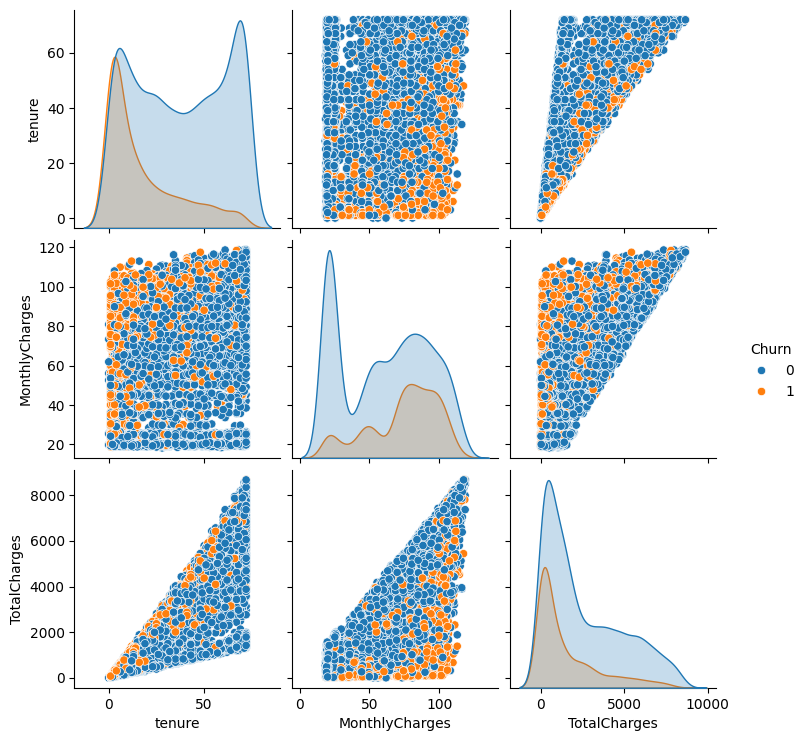

In [89]:
sns.pairplot(data=df_copy[['tenure', 'MonthlyCharges', 'TotalCharges', 'Churn']],hue="Churn")

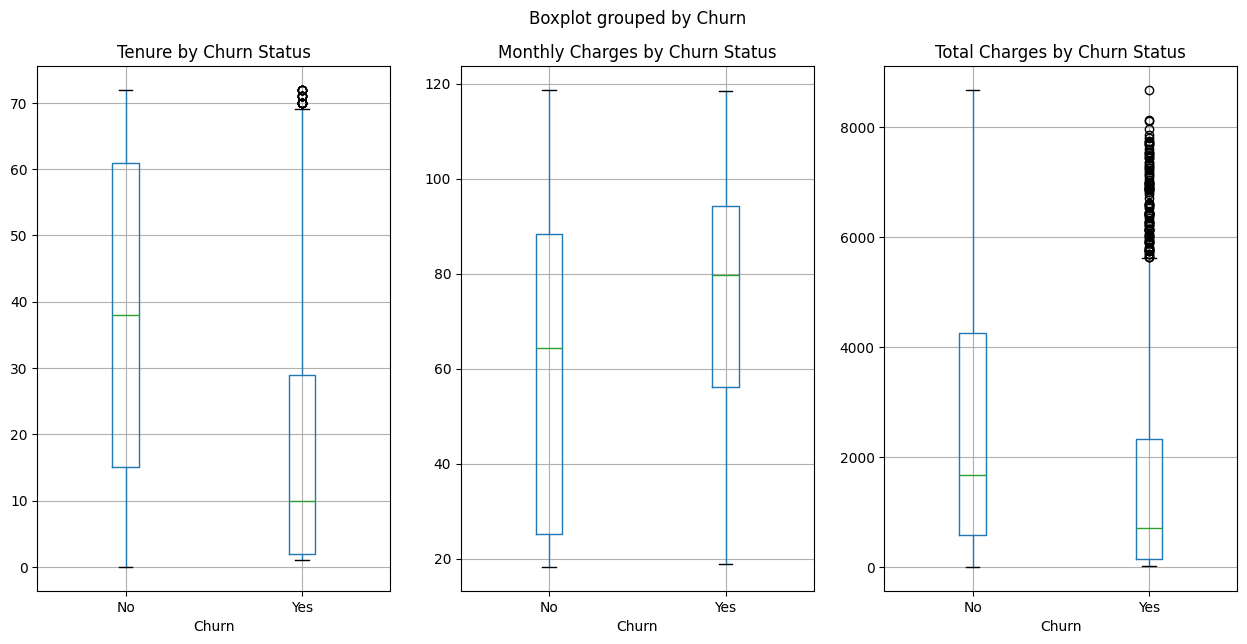

In [24]:
#Feature interactions with churn
fig, axes = plt.subplots(1, 3, figsize=(15, 7))

df_copy.boxplot(column='tenure', by='Churn', ax=axes[0])
axes[0].set_title('Tenure by Churn Status')

df_copy.boxplot(column='MonthlyCharges', by='Churn', ax=axes[1])
axes[1].set_title('Monthly Charges by Churn Status')

df_copy.boxplot(column='TotalCharges', by='Churn', ax=axes[2])
axes[2].set_title('Total Charges by Churn Status')

plt.show()

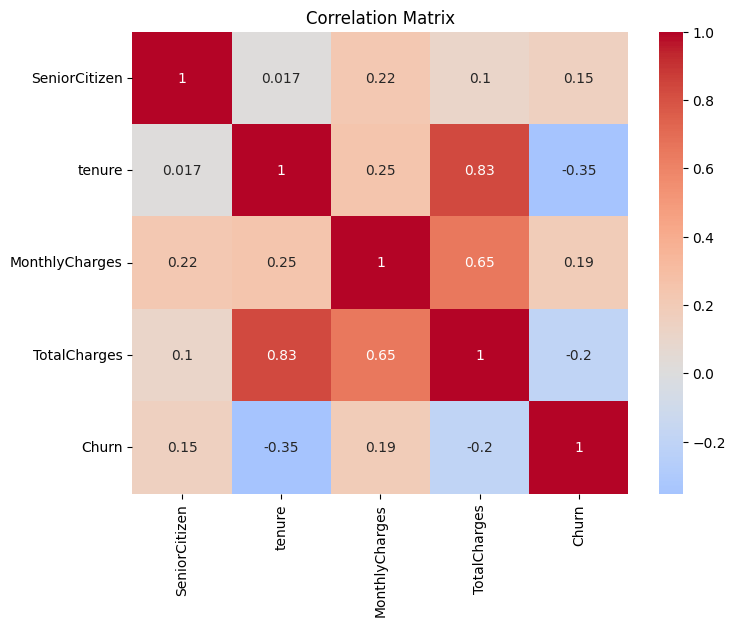

In [25]:
#Correlation Heatmap
df_corr = df_copy
df_corr['Churn'] = df_corr['Churn'].map({'Yes': 1, 'No': 0})

# Select numeric only
corr = df_corr.select_dtypes(include=[np.number]).corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Matrix')
plt.show()

In [26]:
df_copy.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [27]:
df_copy=df_copy.drop("customerID",axis=1)

In [28]:
df_copy.head().T

,0,1,2,3,4
gender,Female,Male,Male,Male,Female
SeniorCitizen,0,0,0,0,0
Partner,Yes,No,No,No,No
Dependents,No,No,No,No,No
tenure,1,34,2,45,2
PhoneService,No,Yes,Yes,No,Yes
MultipleLines,No phone service,No,No,No phone service,No
InternetService,DSL,DSL,DSL,DSL,Fiber optic
OnlineSecurity,No,Yes,Yes,Yes,No
OnlineBackup,Yes,No,Yes,No,No


In [29]:
#Covert Yes/No columns to 1/0
for col in df_copy.columns:
  if set(df_copy[col].unique())==set(['Yes','No']):
    df_copy[col]=df_copy[col].map({'Yes':1,'No':0})

In [30]:
df_copy.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   int64  
 3   Dependents        7043 non-null   int64  
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   int64  
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   int64  
 16  PaymentMethod     7043 non-null   object 


In [31]:
#Convert Gender Column Male=1 Female=0
if 'gender' in df_copy.columns:
  df_copy['gender']=df_copy['gender'].map({'Male':1,'Female':0})

df_copy['gender'].dtypes

dtype('int64')

In [32]:
X=df_copy.drop('Churn',axis=1)
y=df_copy['Churn']

In [33]:
for col in df_copy.columns:
  if (df_copy[col].dtypes)=='object':
    print(col)

MultipleLines
InternetService
OnlineSecurity
OnlineBackup
DeviceProtection
TechSupport
StreamingTV
StreamingMovies
Contract
PaymentMethod


In [34]:
#Split the data
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.3,random_state=42)

In [35]:
#Scale the numerical data
numerical_features = ["tenure", "MonthlyCharges","TotalCharges"]
Scaler = StandardScaler()

X_train[numerical_features] = Scaler.fit_transform(X_train[numerical_features])
X_test[numerical_features] = Scaler.transform(X_test[numerical_features])


In [36]:
#One-hot encoder
categorical_features=['MultipleLines','InternetService','OnlineSecurity','OnlineBackup','DeviceProtection','TechSupport','StreamingTV','StreamingMovies','Contract','PaymentMethod']
one_hot=OneHotEncoder()
transformer=ColumnTransformer([("one_hot",
                               one_hot,
                               categorical_features)],
                              remainder="passthrough")
X_train=transformer.fit_transform(X_train)
X_test=transformer.transform(X_test)

# **DecisionTreeClassifier**

In [37]:
base_model_dt=DecisionTreeClassifier(random_state=42)
base_model_dt.fit(X_train,y_train)

DecisionTreeClassifier(random_state=42)

In [38]:
base_model_dt.score(X_test,y_test)

0.7321344060577378

In [40]:
#fit the model with weighted class
model_1=DecisionTreeClassifier(random_state=42,class_weight="balanced")
model_1.fit(X_train,y_train)


DecisionTreeClassifier(class_weight='balanced', random_state=42)

In [42]:
model_1.score(X_test,y_test)

0.7382867960246096

### Hyperparameter Tuning with RandomizedSearchCV


In [43]:
rs_grid={
    "criterion":["gini", "entropy", "log_loss"],
    "max_depth":np.arange(1,10),
    "min_samples_split":np.arange(2,10),
    "min_samples_leaf":[1,2,4,5,7,8,10]

}

np.random.seed(42)
rs=RandomizedSearchCV(model_1,
                      param_distributions=rs_grid,
                      cv=5,
                      n_iter=30,
                      verbose=True)

rs.fit(X_train,y_train)
rs.best_params_

Fitting 5 folds for each of 30 candidates, totalling 150 fits


{'min_samples_split': np.int64(7),
 'min_samples_leaf': 4,
 'max_depth': np.int64(5),
 'criterion': 'log_loss'}

In [44]:
rs.score(X_test,y_test)

0.7586370089919545

### Hyperparameter Tuning with gridSearchCV

In [45]:
gs_grid={
    "criterion":["entropy", "log_loss"],
    "max_depth":[5],
    "min_samples_split":[5,6,7,9],
    "min_samples_leaf":[3,4,6,8]
}

np.random.seed(42)

gs=GridSearchCV(model_1,
                param_grid=gs_grid,
                cv=5,
                verbose=True)

gs.fit(X_train,y_train)
gs.best_params_

Fitting 5 folds for each of 32 candidates, totalling 160 fits


{'criterion': 'entropy',
 'max_depth': 5,
 'min_samples_leaf': 4,
 'min_samples_split': 5}

In [46]:
gs.score(X_test,y_test)

0.7586370089919545

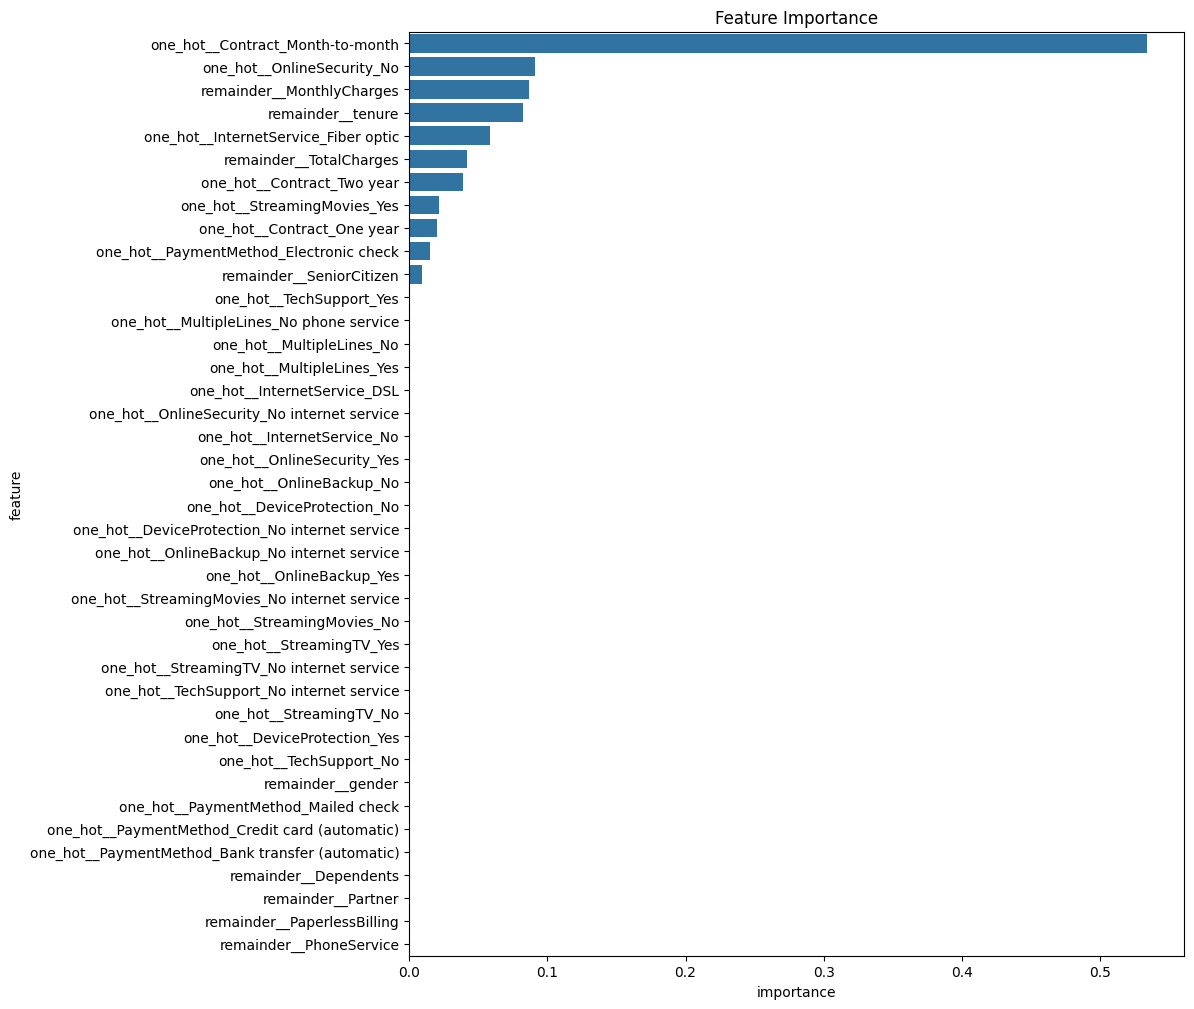

In [47]:
feature_importance = gs.best_estimator_.feature_importances_
feature_names = transformer.get_feature_names_out()

fi_df = pd.DataFrame({
    'feature': feature_names,
    'importance': feature_importance
}).sort_values(by='importance', ascending=False)

plt.figure(figsize=(10, 12))
sns.barplot(data=fi_df, x='importance', y='feature')
plt.title('Feature Importance')
plt.show()

In [48]:
#save
import pickle
pickle.dump(gs,open("best_churn_decision_tree_model.pkl","wb"))

### Evaluating Decision Tree

#### Evaluating base model

In [72]:
y_preds_base=base_model_dt.predict(X_test)

In [73]:
confusion_matrix(y_test,y_preds_base)

array([[1269,  270],
       [ 296,  278]])

In [74]:
print(classification_report(y_test,y_preds_base))


              precision    recall  f1-score   support

           0       0.81      0.82      0.82      1539
           1       0.51      0.48      0.50       574

    accuracy                           0.73      2113
   macro avg       0.66      0.65      0.66      2113
weighted avg       0.73      0.73      0.73      2113



#### Evaluating weighted model

In [75]:
y_preds_weighted_dt=model_1.predict(X_test)

In [76]:
confusion_matrix(y_test,y_preds_weighted_dt)

array([[1285,  254],
       [ 299,  275]])

In [78]:
print(classification_report(y_test,y_preds_weighted_dt))

              precision    recall  f1-score   support

           0       0.81      0.83      0.82      1539
           1       0.52      0.48      0.50       574

    accuracy                           0.74      2113
   macro avg       0.67      0.66      0.66      2113
weighted avg       0.73      0.74      0.73      2113



#### Evaluating tuned model

In [80]:
y_preds_tuned_dt=gs.predict(X_test)

In [81]:
dt_accuracy=accuracy_score(y_test,y_preds_tuned_dt)
print(f"Accuracy: {dt_accuracy}")

Accuracy: 0.7586370089919545


In [82]:
dt_precision=precision_score(y_test,y_preds_tuned_dt,average='weighted')
print(f"Precision: {dt_precision}")
dt_percision_2=precision_score(y_test,y_preds_tuned_dt,average="macro")
print(f"Precision_macro: {dt_percision_2}")

Precision: 0.807375925681703
Precision_macro: 0.7227841008514742


In [83]:
dt_recall=recall_score(y_test,y_preds_tuned_dt,average="weighted")
print(f"Recall: {dt_recall}")
dt_recall_2=recall_score(y_test,y_preds_tuned_dt,average="macro")
print(f"Recall_macro: {dt_recall_2}")

Recall: 0.7586370089919545
Recall_macro: 0.7709495056521158


In [84]:
dt_f1=f1_score(y_test,y_preds_tuned_dt,average="weighted")
print(f"F1 Score: {dt_f1}")
dt_f1_2=f1_score(y_test,y_preds_tuned_dt,average="macro")
print(f"F1 Score_macro: {dt_f1_2}")

F1 Score: 0.7701820280764724
F1 Score_macro: 0.7301066920456822


In [66]:
y_probs_dt=gs.predict_proba(X_test)[:,1]

In [67]:
auc_dt=roc_auc_score(y_test,y_probs_dt)
print(f"AUC-ROC Score: {auc_dt}")

AUC-ROC Score: 0.8356290455135128


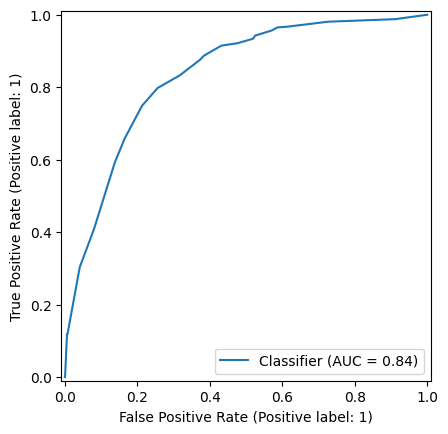

In [68]:
RocCurveDisplay.from_predictions(y_test,y_probs_dt)

In [85]:
confusion_matrix(y_test, y_preds_tuned_dt)

array([[1145,  394],
       [ 116,  458]])

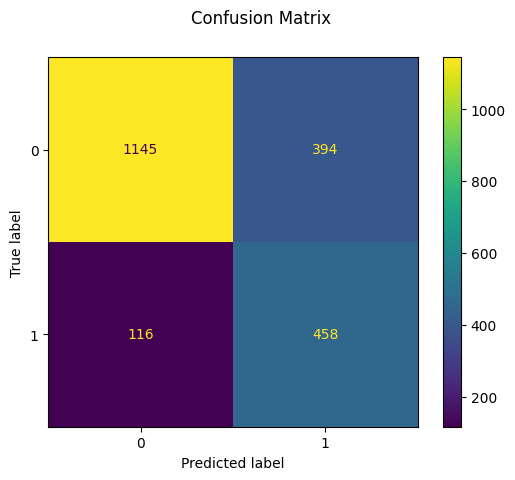

In [86]:
Confy_mat=ConfusionMatrixDisplay.from_predictions(y_test,y_preds_tuned_dt)
Confy_mat.figure_.suptitle("Confusion Matrix")
plt.show()

In [87]:
print(classification_report(y_test,y_preds_tuned_dt))

              precision    recall  f1-score   support

           0       0.91      0.74      0.82      1539
           1       0.54      0.80      0.64       574

    accuracy                           0.76      2113
   macro avg       0.72      0.77      0.73      2113
weighted avg       0.81      0.76      0.77      2113



#**Neural Network**

In [88]:
import tensorflow as tf
import numpy as np
import random

random_set_seed = 42

random.seed(random_set_seed)
np.random.seed(random_set_seed)
tf.random.set_seed(random_set_seed)

In [ ]:
from sklearn.utils.class_weight import compute_class_weight
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weights = {0: class_weights[0], 1: class_weights[1]}

In [ ]:
# Build the model
def build_model(input_shape):
    model = tf.keras.models.Sequential([
        tf.keras.layers.Input(shape=input_shape),
        tf.keras.layers.Dense(64, activation='relu'),
        tf.keras.layers.Dropout(0.5),
        tf.keras.layers.Dense(32, activation='relu'),
        tf.keras.layers.Dropout(0.5),
        tf.keras.layers.Dense(1, activation='sigmoid')
    ])
    return model


input_shape = (X_train.shape[1],)
model_2 = build_model(input_shape)

In [ ]:
#compile the model
model_2.compile(optimizer='adam',
                loss='binary_crossentropy',
                metrics = ['accuracy'])

In [ ]:
#early stopping
early_stopping_main=tf.keras.callbacks.EarlyStopping(monitor='val_loss',patience=10,restore_best_weights=True)

#model Summary
model_2.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         2,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,737 (18.50 KB)

 Trainable params: 4,737 (18.50 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
X_train_final,X_val,y_train_final,y_val=train_test_split(X_train,y_train,test_size=0.2,random_state=42)

In [ ]:
#train the model
history=model_2.fit(
    X_train_final,y_train_final,
    epochs=200,
    batch_size=32,
    class_weight=class_weights,
    validation_data=(X_val,y_val),
    callbacks=[early_stopping_main],
    verbose=1
)

Epoch 1/200
124/124 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.6154 - loss: 0.6700 - val_accuracy: 0.7191 - val_loss: 0.5435
Epoch 2/200
124/124 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7064 - loss: 0.5803 - val_accuracy: 0.7363 - val_loss: 0.5031
Epoch 3/200
124/124 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7410 - loss: 0.5457 - val_accuracy: 0.7414 - val_loss: 0.4891
Epoch 4/200
124/124 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7382 - loss: 0.5423 - val_accuracy: 0.7505 - val_loss: 0.4791
Epoch 5/200
124/124 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7243 - loss: 0.5440 - val_accuracy: 0.7495 - val_loss: 0.4767
Epoch 6/200
124/124 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7403 - loss: 0.5167 - val_accuracy: 0.7515 - val_loss: 0.4755
Epoch 7/200
124/124 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7492 - loss: 0.5070 - val_accuracy: 0.7454 - val_loss: 0.4802
Epoch 8/200
124/124 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7394 - loss: 0.5110 - val_accu

In [ ]:
#Evaluate the model
loss,accuracy=model_2.evaluate(X_test,y_test)
print("Test Loss: ",loss)
print("Test Accuracy: ",accuracy)

67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7850 - loss: 0.4481
Test Loss:  0.45842257142066956
Test Accuracy:  0.7723615765571594


In [ ]:
pip install -q keras-tuner

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.4/129.4 kB 10.5 MB/s eta 0:00:00


In [ ]:
import shutil
shutil.rmtree("tuner_output", ignore_errors=True)

In [ ]:
import keras_tuner as kt

#Tuning NN
def build_hyper_model(hp):
  model=tf.keras.Sequential()
  model.add(tf.keras.layers.Input(shape=(X_train.shape[1],)))
  hp_layers=hp.Int('num_layers',min_value=1,max_value=3,step=1)
  for i in range(hp_layers):
    units=hp.Int(f'layer_{i}',min_value=16,max_value=256,step=16)
    activation=hp.Choice(f'activation_{i}',values=['relu','tanh'])
    model.add(tf.keras.layers.Dense(units,activation=activation))

    dropout_rate=hp.Float(f'dropout_{i}',min_value=0.0,max_value=0.6,step=0.1)
    model.add(tf.keras.layers.Dropout(dropout_rate))


  model.add(tf.keras.layers.Dense(1, activation='sigmoid'))

  hp_learning_rate=hp.Choice('learning_rate',values=[1e-2,1e-3,1e-4])

  model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=hp_learning_rate),
                loss='binary_crossentropy',
                metrics = ['accuracy'])

  return model

In [ ]:
tuner=kt.Hyperband(build_hyper_model,
                   objective='val_accuracy',
                   max_epochs=30,
                   factor=3,
                   seed=42,
                   directory='tuner_output',
                   project_name='nn_tuning_telco')

In [ ]:
early_stopping=tf.keras.callbacks.EarlyStopping(monitor='val_loss',patience=5,restore_best_weights=True)


In [ ]:
tuner.search(X_train_final,y_train_final,validation_data=(X_val,y_val),callbacks=[early_stopping],class_weight=class_weights)

Trial 90 Complete [00h 00m 09s]
val_accuracy: 0.7748478651046753

Best val_accuracy So Far: 0.7941176295280457
Total elapsed time: 00h 08m 42s


In [ ]:
best_hps=tuner.get_best_hyperparameters()[0]
best_hps.values

{'num_layers': 2,
 'layer_0': 176,
 'activation_0': 'tanh',
 'dropout_0': 0.4,
 'learning_rate': 0.01,
 'layer_1': 224,
 'activation_1': 'tanh',
 'dropout_1': 0.2,
 'layer_2': 256,
 'activation_2': 'tanh',
 'dropout_2': 0.0,
 'tuner/epochs': 30,
 'tuner/initial_epoch': 10,
 'tuner/bracket': 3,
 'tuner/round': 3,
 'tuner/trial_id': '0046'}

In [ ]:
model_2=tuner.hypermodel.build(best_hps)
history=model_2.fit(
    X_train_final,y_train_final,
    epochs=200,
    batch_size=32,
    class_weight=class_weights,
    validation_data=(X_val,y_val),
    callbacks=[early_stopping_main],
    verbose=1
)

Epoch 1/200
124/124 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.7104 - loss: 0.6528 - val_accuracy: 0.7657 - val_loss: 0.4549
Epoch 2/200
124/124 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7256 - loss: 0.5606 - val_accuracy: 0.7931 - val_loss: 0.4368
Epoch 3/200
124/124 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7337 - loss: 0.5515 - val_accuracy: 0.7850 - val_loss: 0.4355
Epoch 4/200
124/124 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7362 - loss: 0.5481 - val_accuracy: 0.7809 - val_loss: 0.4432
Epoch 5/200
124/124 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.7416 - loss: 0.5420 - val_accuracy: 0.7759 - val_loss: 0.4472
Epoch 6/200
124/124 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.7342 - loss: 0.5500 - val_accuracy: 0.7677 - val_loss: 0.4535
Epoch 7/200
124/124 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7362 - loss: 0.5375 - val_accuracy: 0.7515 - val_loss: 0.4632
Epoch 8/200
124/124 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7258 - loss: 0.5563 - val_accu

In [ ]:
#Evaluate the model
loss,accuracy=model_2.evaluate(X_test,y_test)
print("Test Loss: ",loss)
print("Test Accuracy: ",accuracy)

67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8052 - loss: 0.4157
Test Loss:  0.4233056306838989
Test Accuracy:  0.7946048378944397


In [ ]:
model_2.save("best_churn_NN_model.keras")

In [ ]:
from tensorflow.keras.models import load_model

model = load_model("best_churn_NN_model.keras")


## Evaluating Neural Netwoek

In [ ]:
y_preds_prob=model_2.predict(X_test)

67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step


In [ ]:
y_preds_prob

array([[0.71800923],
       [0.12786077],
       [0.02944105],
       ...,
       [0.02841047],
       [0.5090852 ],
       [0.27128267]], dtype=float32)

In [ ]:
y_preds=(y_preds_prob>0.5).astype(int)

In [ ]:
print(classification_report(y_test,y_preds))

              precision    recall  f1-score   support

           0       0.87      0.84      0.86      1539
           1       0.61      0.67      0.64       574

    accuracy                           0.79      2113
   macro avg       0.74      0.76      0.75      2113
weighted avg       0.80      0.79      0.80      2113



In [ ]:
confusion_matrix(y_test,y_preds)

array([[1293,  246],
       [ 188,  386]])

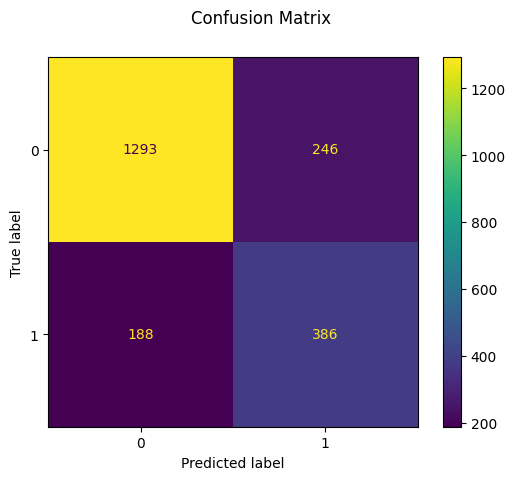

In [ ]:
Confy_mat=ConfusionMatrixDisplay.from_predictions(y_test,y_preds)
Confy_mat.figure_.suptitle("Confusion Matrix")
plt.show()

In [ ]:
auc_nn=roc_auc_score(y_test,y_preds_prob)
print(f"AUC-ROC Score: {auc_nn}")

AUC-ROC Score: 0.850475330150127


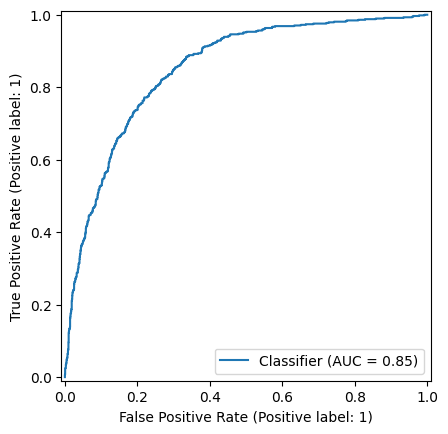

In [ ]:
RocCurveDisplay.from_predictions(y_test,y_preds_prob)

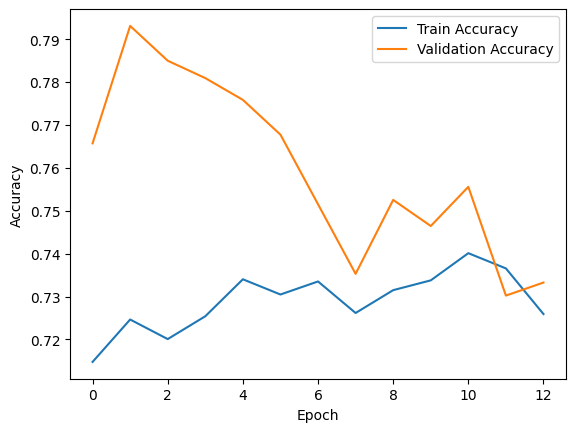

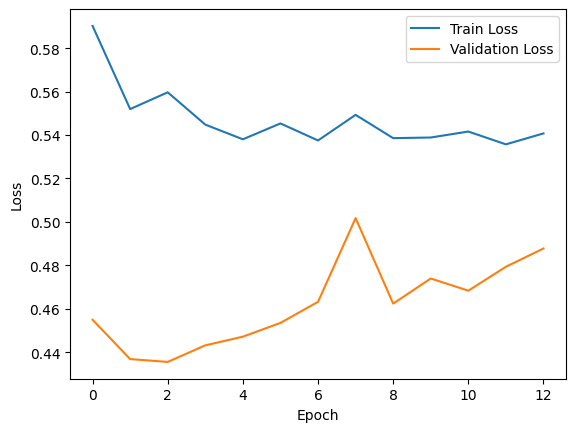

In [ ]:
# Accuracy
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# Loss
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [ ]:
for threshold in [0.3, 0.35, 0.4, 0.45, 0.5]:
    y_pred = (y_preds_prob >= threshold).astype(int)
    recall = recall_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    print(f"Threshold {threshold}: Recall={recall:.3f}, Precision={precision:.3f}")

Threshold 0.3: Recall=0.889, Precision=0.490
Threshold 0.35: Recall=0.843, Precision=0.513
Threshold 0.4: Recall=0.775, Precision=0.556
Threshold 0.45: Recall=0.726, Precision=0.590
Threshold 0.5: Recall=0.672, Precision=0.611


In [ ]:
# Use optimal threshold
optimal_threshold = 0.35
y_pred_optimal = (y_preds_prob >= optimal_threshold).astype(int)

cm = confusion_matrix(y_test, y_pred_optimal)
print("NEURAL NETWORK WITH OPTIMIZED THRESHOLD (0.35)")
print(f"Confusion Matrix:\n{cm}")
print(f"\n{classification_report(y_test, y_pred_optimal)}")


NEURAL NETWORK WITH OPTIMIZED THRESHOLD (0.35)
Confusion Matrix:
[[1080  459]
 [  90  484]]

              precision    recall  f1-score   support

           0       0.92      0.70      0.80      1539
           1       0.51      0.84      0.64       574

    accuracy                           0.74      2113
   macro avg       0.72      0.77      0.72      2113
weighted avg       0.81      0.74      0.75      2113

